In [6]:
# Gerekli kütüphaneler 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In [8]:
# Lojistik Regresyon final model sonuçlarının yüklenmesi

final_tahminler = pd.read_csv(
    "../data/lojistik_regresyon_tahminleri.csv"
)

print("Tahmin veri setinin boyutu:", final_tahminler.shape)
final_tahminler.head()

Tahmin veri setinin boyutu: (1407, 3)


,Gercek_Churn,Tahmin_Churn,Churn_Olasiligi
0,0,0,0.018022
1,0,1,0.591832
2,0,0,0.004892
3,1,0,0.201424
4,0,0,0.103762


In [10]:
y_true = final_tahminler["Gercek_Churn"]
y_pred = final_tahminler["Tahmin_Churn"]
y_prob = final_tahminler["Churn_Olasiligi"]

print("Gerçek değer sayısı:", len(y_true))
print("Tahmin sayısı:", len(y_pred))

Gerçek değer sayısı: 1407
Tahmin sayısı: 1407


In [12]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[918 115]
 [159 215]]


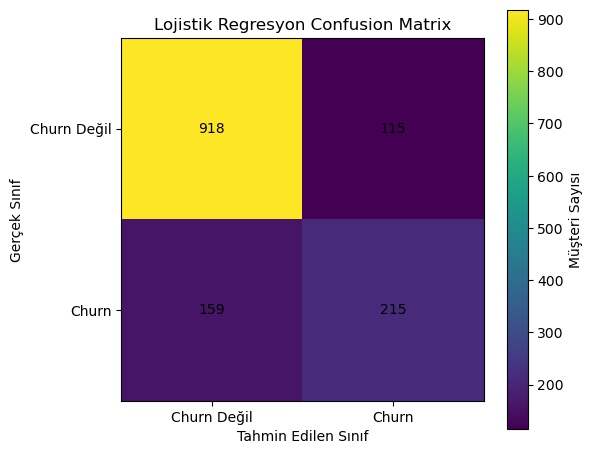

In [16]:
# Confusion Matrix görselleştirmesi

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Lojistik Regresyon Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")

plt.xticks([0, 1], ["Churn Değil", "Churn"])
plt.yticks([0, 1], ["Churn Değil", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Müşteri Sayısı")
plt.tight_layout()
plt.show()

In [18]:
# Hata türlerinin hesaplanması

TN, FP, FN, TP = cm.ravel()

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

print("\nToplam yanlış tahmin:", FP + FN)
print("Toplam doğru tahmin:", TN + TP)

True Negative (TN): 918
False Positive (FP): 115
False Negative (FN): 159
True Positive (TP): 215

Toplam yanlış tahmin: 274
Toplam doğru tahmin: 1133


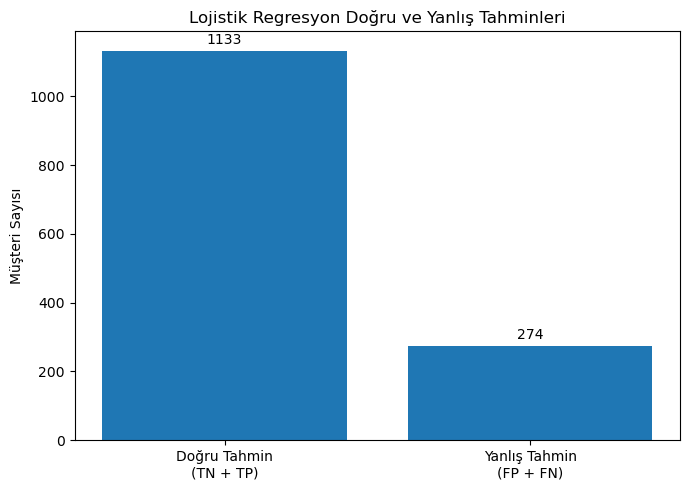

In [20]:
# Doğru ve yanlış tahminlerin görselleştirilmesi

etiketler = [
    "Doğru Tahmin\n(TN + TP)",
    "Yanlış Tahmin\n(FP + FN)"
]

degerler = [
    TN + TP,
    FP + FN
]

plt.figure(figsize=(7, 5))

plt.bar(etiketler, degerler)

plt.ylabel("Müşteri Sayısı")
plt.title("Lojistik Regresyon Doğru ve Yanlış Tahminleri")

for i, deger in enumerate(degerler):
    plt.text(
        i,
        deger + 20,
        str(deger),
        ha="center"
    )

plt.tight_layout()
plt.show()

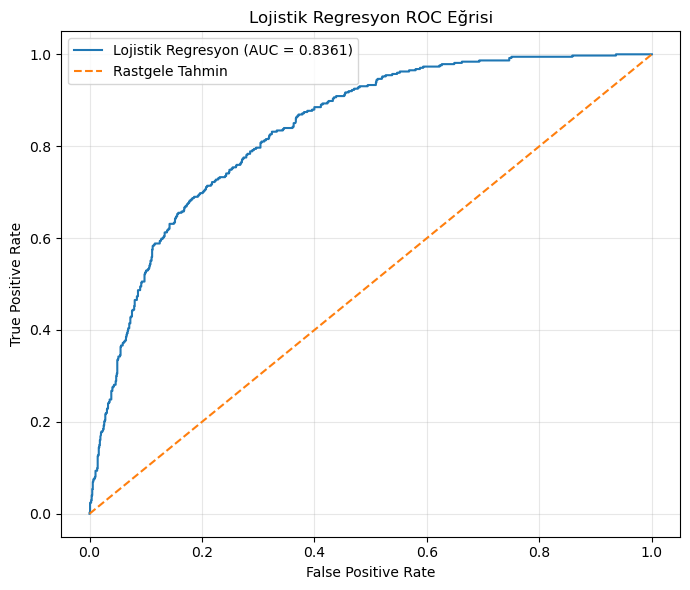

ROC-AUC: 0.8361


In [22]:
# ROC Curve ve ROC-AUC

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Lojistik Regresyon (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Rastgele Tahmin"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Lojistik Regresyon ROC Eğrisi")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

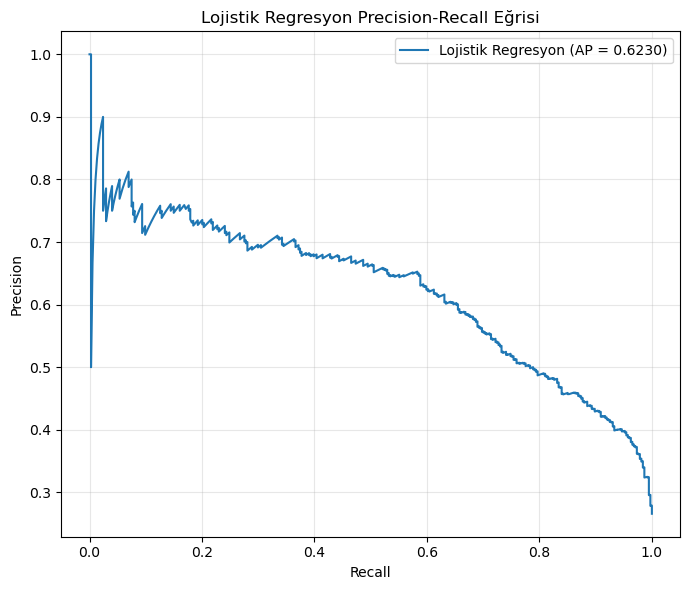

Average Precision: 0.6230


In [24]:
# Precision-Recall Curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_true,
    y_prob
)

average_precision = average_precision_score(
    y_true,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Lojistik Regresyon (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Lojistik Regresyon Precision-Recall Eğrisi")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision: {average_precision:.4f}")

In [26]:
# Genel model değerlendirmesi

print("=== Lojistik Regresyon Genel Değerlendirmesi ===")

print(f"Test veri setindeki müşteri sayısı: {len(y_true)}")
print(f"Doğru tahmin sayısı: {TN + TP}")
print(f"Yanlış tahmin sayısı: {FP + FN}")

print("\nHata dağılımı:")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")

print("\nModel performansı:")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1-score: {f1_score(y_true, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

=== Lojistik Regresyon Genel Değerlendirmesi ===
Test veri setindeki müşteri sayısı: 1407
Doğru tahmin sayısı: 1133
Yanlış tahmin sayısı: 274

Hata dağılımı:
False Positive: 115
False Negative: 159

Model performansı:
Accuracy: 0.8053
Precision: 0.6515
Recall: 0.5749
F1-score: 0.6108
ROC-AUC: 0.8361
Average Precision: 0.6230
